# Analyse bivariée (Gènes - Halo)

### Packages necessaires

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
import seaborn as sns
import plotly.graph_objects as go

In [2]:
#import sys
#!{sys.executable} -m pip install statsmodels

### Exploration et traitement des données

In [3]:
data = pd.read_csv("../data/sortie/dataset_complet_sans_auto_inhibition.csv")

# Suppression des NA
df_clean = data.dropna()

print(f"Lignes avant nettoyage : {len(data)}")
print(f"Lignes après nettoyage : {len(df_clean)}")
print(f"Lignes supprimées : {len(data) - len(df_clean)}")

Lignes avant nettoyage : 1259
Lignes après nettoyage : 964
Lignes supprimées : 295


In [4]:
# Compter le nombre de souches productrices et cibles
nb_productrice = df_clean['productrice'].nunique()
nb_cible = df_clean['cible'].nunique()

print(f"Nombre de productrices distinctes : {nb_productrice}")
print(f"Nombre de cibles distinctes : {nb_cible}")

Nombre de productrices distinctes : 34
Nombre de cibles distinctes : 34


In [5]:
import pandas as pd

# Définition de la variable cible
y = df_clean["halo"].astype(int)

# Suppression des colonnes inutiles
df_clean = df_clean.drop(columns=["halo"], errors="ignore")

# Nombre des variables et observations
nb_obs, nb_total = df_clean.shape

binaires = [c for c in df_clean.columns if set(df_clean[c].unique()) <= {0, 1}]
nb_binaires = len(binaires)
nb_non_binaires = nb_total - nb_binaires

print(f"Nombre d'observations : {nb_obs}")
print(f"Nombre de variables   : {nb_total}")
print(f"Nombre de variables binaires (gènes) : {nb_binaires}")
print(f"Nombre de variables non binaires (pics): {nb_non_binaires}")

Nombre d'observations : 964
Nombre de variables   : 9623
Nombre de variables binaires (gènes) : 774
Nombre de variables non binaires (pics): 8849


In [6]:
# On ne garde que les colonnes binaires
df_genes = df_clean[binaires]
df_genes.shape

(964, 774)

In [7]:
# Vérification de la variabilité des gènes
variabilite = df_genes[binaires].nunique()
genes_constants = variabilite[variabilite == 1].index.tolist()
genes_variables = variabilite[variabilite > 1].index.tolist()

print(f"Nombre de gènes constants (pas de variabilité) : {len(genes_constants)}")
print(f"Nombre de gènes variables : {len(genes_variables)}")

Nombre de gènes constants (pas de variabilité) : 242
Nombre de gènes variables : 532


In [8]:
# Vérifions la valeur constante (0 ou 1) des gènes
valeurs_constants = {g: df_genes[g].unique()[0] for g in genes_constants}

# Comptage des gènes constants à 0 et à 1
nb_constants_0 = sum(v == 0 for v in valeurs_constants.values())
nb_constants_1 = sum(v == 1 for v in valeurs_constants.values())

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - constants à 0 : {nb_constants_0}")
print(f" - constants à 1 : {nb_constants_1}")

Nombre total de gènes constants : 242
 - constants à 0 : 242
 - constants à 1 : 0


In [9]:
# Vérifions dans la liste des gènes constants, ceux des cibles et productrices
genes_constants_P = [g for g in genes_constants if g.endswith('_P')]
genes_constants_C = [g for g in genes_constants if g.endswith('_C')]

print(f"Nombre total de gènes constants : {len(genes_constants)}")
print(f" - dont gènes productrices (_P) : {len(genes_constants_P)}")
print(f" - dont gènes cibles (_C)       : {len(genes_constants_C)}")

Nombre total de gènes constants : 242
 - dont gènes productrices (_P) : 121
 - dont gènes cibles (_C)       : 121


In [10]:
import pandas as pd

df = pd.read_excel("../data/Features_souches/jointures.xlsx")

In [11]:
import numpy as np

# Calcul de la fréquence de présence (proportion de 1 par colonne)
freq_presence = df.mean()   # moyenne sur toutes les colonnes

# Nombre de souches
nb_souches = len(df)

# Seuils
seuil_toutes_sauf_une = (nb_souches - 1) / nb_souches
seuil_une_souche = 1 / nb_souches

# Comptages
genes_0 = freq_presence[freq_presence == 0].index.tolist()
genes_100 = freq_presence[freq_presence == 1].index.tolist()
genes_toutes_sauf_une = freq_presence[np.isclose(freq_presence, seuil_toutes_sauf_une)].index.tolist()
genes_une_souche = freq_presence[np.isclose(freq_presence, seuil_une_souche)].index.tolist()

# Tableau récapitulatif
tableau_freq = pd.DataFrame({
    "Catégorie": [
        "Présents chez 0 % (absents partout)",
        "Présents chez 100 % (présents partout)",
        "Présents chez toutes sauf 1",
        "Présents dans une seule souche"
    ],
    "Nombre de gènes": [
        len(genes_0),
        len(genes_100),
        len(genes_toutes_sauf_une),
        len(genes_une_souche)
    ]
})

print(tableau_freq)

# Souches absentes ou présentes
souches_absentes = {gene: df.index[df[gene] == 0].tolist() for gene in genes_toutes_sauf_une}
souches_presentes = {gene: df.index[df[gene] == 1].tolist() for gene in genes_une_souche}

df_absences = pd.DataFrame.from_dict(souches_absentes, orient='index', columns=['Souche absente'])
df_presences = pd.DataFrame.from_dict(souches_presentes, orient='index', columns=['Souche présente'])

                                Catégorie  Nombre de gènes
0     Présents chez 0 % (absents partout)              121
1  Présents chez 100 % (présents partout)                0
2             Présents chez toutes sauf 1                0
3          Présents dans une seule souche               25


In [12]:
# Sélection des gènes présents dans une seule souche (somme = 1)
genes_uniquement_une = df.columns[df.sum(axis=0) == 1].tolist()

print(f"Nombre de gènes présents dans une seule souche : {len(genes_uniquement_une)}")
print("Gènes :", genes_uniquement_une)

Nombre de gènes présents dans une seule souche : 25
Gènes : ['ENA.AAA23540.AAA23540.1 Escherichia coli hypothetical protein', 'ENA.AAA23589.AAA23589.1 Plasmid ColBM-Cl139 hypothetical protein', 'ENA.AAA98156.AAA98156.1 Plasmid pKY1 hypothetical protein', 'ENA.AAA98157.AAA98157.1 Plasmid pKY1 immunity protein', 'ENA.AAC16352.AAC16352.1 Escherichia coli microcin V immunity protein', 'ENA.AAC16353.AAC16353.1 Escherichia coli microcin V bacteriocin', 'ENA.CAJ44959.CAJ44959.1 Escherichia coli MchF protein', 'espR3', 'espR4', 'espX2', 'espX6', 'faeC', 'faeD', 'faeI', 'faeJ', 'ibeA', 'kpsT', 'sfaX', 'AAC.3..IId', 'MCR.1', 'QnrS1', 'TEM.208', 'dfrA5', 'dfrA8', 'ramA']


In [13]:
# Les gènes présents chez une seule souche dans la collection
genes_to_remove = genes_uniquement_une

# Génération des noms complets
genes_to_remove_full = [g + "_C" for g in genes_to_remove] + [g + "_P" for g in genes_to_remove]

# Vérification s’ils sont dans df_genes
genes_in_X = [g for g in genes_to_remove_full if g in df_genes.columns]

print(f"Gènes de la liste retrouvés dans df_genes : {len(genes_in_X)} / {len(genes_to_remove_full)}\n")

# Vérification de leur variabilité
check_variabilite = df_genes[genes_in_X].nunique()
constantes = check_variabilite[check_variabilite == 1].index.tolist()
variables = check_variabilite[check_variabilite > 1].index.tolist()

print(f"Nombre de gènes constants dans la liste : {len(constantes)}")
print(f"Nombre de gènes variables dans la liste : {len(variables)}")

Gènes de la liste retrouvés dans df_genes : 50 / 50

Nombre de gènes constants dans la liste : 0
Nombre de gènes variables dans la liste : 50


In [14]:
# Suppression des gènes constants
df_genes = df_genes.drop(columns=genes_constants)

In [15]:
print(f"Shape finale : {df_genes.shape}")

Shape finale : (964, 532)


In [16]:
# Vérifions que tous les sous-ensembles ont les mêmes index
assert df_genes.index.equals(y.index), " Index non alignés entre matrice de gènes et y"

# Si ça passe sans erreur,
print("Index parfaitement alignés entre tous les blocs.")

Index parfaitement alignés entre tous les blocs.


In [17]:
# Vérification de leur présence exacte
present_exact = [g for g in genes_to_remove_full if g in df_genes.columns]

print(f"Colonnes trouvées (présence exacte) : {len(present_exact)} / {len(genes_to_remove_full)}")

Colonnes trouvées (présence exacte) : 50 / 50


In [18]:
#  Identifier les colonnes à supprimer
cols_to_remove = [col for col in genes_to_remove_full if col in df_genes.columns]

print(f"{len(genes_to_remove_full)} colonnes candidates à la suppression.")
print(f"{len(cols_to_remove)} colonnes réellement supprimées.")

# Suppression dans le DataFrame
df_genes = df_genes.drop(columns=cols_to_remove)

50 colonnes candidates à la suppression.
50 colonnes réellement supprimées.


In [19]:
print(f"Shape finale : {df_genes.shape}")

Shape finale : (964, 482)


In [20]:
df_genes.head()

,ENA.AAA23080.AAA23080.1 Plasmid ColE6-CT14 hypothetical protein_P,ENA.AAA23182.AAA23182.2 Plasmid ColIa colicin Ia structural protein_P,ENA.AAA23183.AAA23183.1 Plasmid ColIa colicin Ia immunity protein_P,ENA.AAA23188.AAA23188.1 Plasmid ColIb hypothetical protein_P,ENA.AAA23189.AAA23189.1 Plasmid ColIb hypothetical protein_P,ENA.AAA23594.AAA23594.1 Plasmid ColBM-Cl139 hypothetical protein_P,ENA.AAB61768.AAB61768.1 Escherichia coli ferrichrome-iron receptor_P,ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_P,ENA.AAC16351.AAC16351.1 Escherichia coli microcin V bacteriocin_P,ENA.AAC73892.AAC73892.1 Escherichia coli str. K-12 substr. MG1655 iron catecholate outer membrane transporter Fiu_P,...,pmrF_C,qacH_C,sul1_C,sul2_C,sul3_C,tet.A._C,tet.B._C,tolC_C,ugd_C,yojI_C
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## Analyse univariee

In [21]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

results = []

for gene in df_genes.columns:
    # Tableau de contingence
    contingency = pd.crosstab(df_genes[gene], y)

    if contingency.shape == (2, 2):  # s'assurer qu'il y a bien les deux modalités
        chi2, p, dof, exp = chi2_contingency(contingency)
        # Coefficient phi = sqrt(chi2/n)
        phi = np.sqrt(chi2 / len(df_genes))
        results.append((gene, chi2, p, phi))
    else:
        # Si le gène est constant (0 ou 1 partout)
        results.append((gene, np.nan, np.nan, np.nan))

# Création d’un DataFrame des résultats
df_results = pd.DataFrame(results, columns=["Gene", "Chi2", "p_value", "Phi"])

# Correction des p-values (FDR Benjamini-Hochberg)
df_results["p_adj"] = multipletests(df_results["p_value"].dropna(), method='fdr_bh')[1].tolist() + \
                      [np.nan]*(len(df_results) - df_results["p_value"].dropna().shape[0])

# Tri par corrélation absolue
df_results = df_results.sort_values("Phi", ascending=False).reset_index(drop=True)

# Afficher les gènes les plus associés
df_results.head(30)

,Gene,Chi2,p_value,Phi,p_adj
0,gtrB_C,153.951328,2.373371e-35,0.399626,1.143965e-32
1,ENA.CAA40744.CAA40744.1 Escherichia coli cvaB ...,116.235315,4.221180e-27,0.347241,1.017304e-24
2,QnrB5_C,105.359259,1.018833e-24,0.330596,1.236719e-22
3,gtrA_C,105.344744,1.026323e-24,0.330573,1.236719e-22
4,ENA.AAC16350.AAC16350.1 Escherichia coli micro...,94.879225,2.023625e-22,0.313723,1.950774e-20
5,APH.3....Ib_C,93.229198,4.657592e-22,0.310984,3.207085e-20
6,APH.6..Id_C,93.229198,4.657592e-22,0.310984,3.207085e-20
7,iucC_C,87.444447,8.668052e-21,0.301181,3.481668e-19
8,iucA_C,87.444447,8.668052e-21,0.301181,3.481668e-19
9,iutA_C,87.444447,8.668052e-21,0.301181,3.481668e-19


In [22]:
results = []

# Calcul du chi² et du phi signé
for gene in df_genes.columns:
    contingency = pd.crosstab(df_genes[gene], y)

    if contingency.shape == (2, 2):  # gène non constant
        chi2, p, dof, exp = chi2_contingency(contingency)
        phi = np.sqrt(chi2 / len(df_genes))
        corr = df_genes[gene].corr(y)
        phi_signed = np.sign(corr) * phi
        results.append((gene, chi2, p, phi_signed))
    else:
        results.append((gene, np.nan, np.nan, np.nan))

# Création du DataFrame des résultats
df_results = pd.DataFrame(results, columns=["Gene", "Chi2", "p_value", "Phi_signed"])

# Correction des p-values (Benjamini–Hochberg)
mask_valid = df_results["p_value"].notna()
df_results.loc[mask_valid, "p_adj"] = multipletests(
    df_results.loc[mask_valid, "p_value"], method='fdr_bh'
)[1]

# Tri par valeur absolue du Phi signé
df_results["Phi_abs"] = df_results["Phi_signed"].abs()
df_results = df_results.sort_values("Phi_abs", ascending=False).reset_index(drop=True)

# Comptage des gènes positifs et négatifs
n_pos = (df_results["Phi_signed"] > 0).sum()
n_neg = (df_results["Phi_signed"] < 0).sum()

print(f"Nombre de gènes corrélés positivement : {n_pos}")
print(f"Nombre de gènes corrélés négativement : {n_neg}")

# Affichage des 20 gènes les plus corrélés
top20 = df_results.head(20)[["Gene", "Phi_signed", "p_adj"]]
print("\n20 gènes les plus corrélés à la présence ou absence de halo :")
display(
    top20.style.background_gradient(subset=["Phi_signed"], cmap="coolwarm", axis=None)
         .format({"Phi_signed": "{:.3f}", "p_adj": "{:.2e}"})
)

Nombre de gènes corrélés positivement : 312
Nombre de gènes corrélés négativement : 165

20 gènes les plus corrélés à la présence ou absence de halo :


,Gene,Phi_signed,p_adj
0,gtrB_C,0.400,1.14e-32
1,ENA.CAA40744.CAA40744.1 Escherichia coli cvaB protein_C,-0.347,1.02e-24
2,QnrB5_C,0.331,1.24e-22
3,gtrA_C,0.331,1.24e-22
4,ENA.AAC16350.AAC16350.1 Escherichia coli microcin V immunity protein_C,-0.314,1.95e-20
5,APH.3....Ib_C,-0.311,3.21e-20
6,APH.6..Id_C,-0.311,3.21e-20
7,iucC_C,-0.301,3.48e-19
8,iucA_C,-0.301,3.48e-19
9,iutA_C,-0.301,3.48e-19


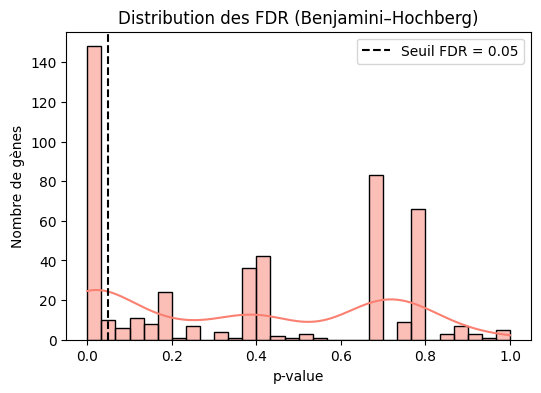

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df_results["p_adj"].dropna(), bins=30, color="salmon", kde=True)
plt.axvline(0.05, color="black", linestyle="--", linewidth=1.5, label="Seuil FDR = 0.05")
plt.title("Distribution des FDR (Benjamini–Hochberg)")
plt.xlabel("p-value")
plt.ylabel("Nombre de gènes")
plt.legend()
plt.show()

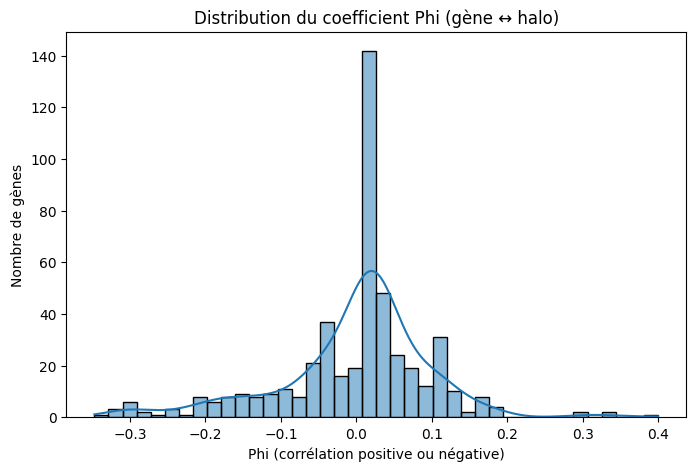

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_results["Phi_signed"].dropna(), bins=40, kde=True)
plt.title("Distribution du coefficient Phi (gène ↔ halo)")
plt.xlabel("Phi (corrélation positive ou négative)")
plt.ylabel("Nombre de gènes")
plt.show()

/tmp/ipykernel_9587/1900949299.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_9587/1900949299.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


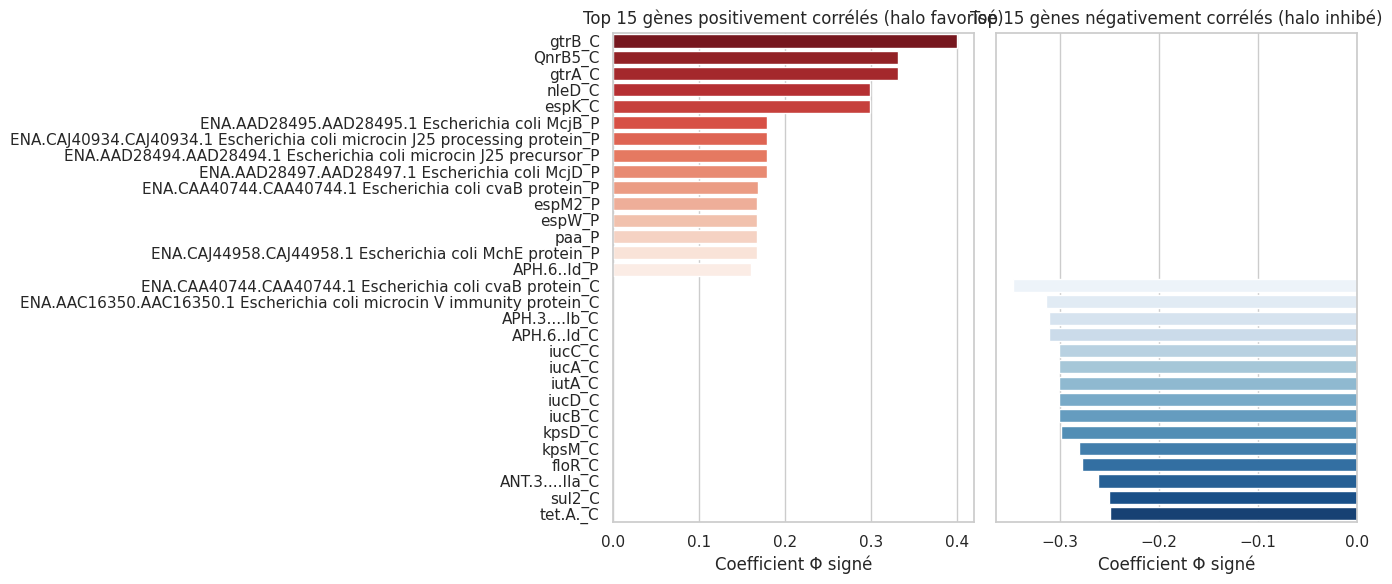

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection top gènes positifs et négatifs à partir de df_results déjà calculé
top_pos = (
    df_results[df_results["Phi_signed"] > 0]
    .sort_values("Phi_signed", ascending=False)
    .head(15)
)

top_neg = (
    df_results[df_results["Phi_signed"] < 0]
    .sort_values("Phi_signed", ascending=True)
    .head(15)
)

# Visualisation
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Positifs
sns.barplot(
    data=top_pos,
    y="Gene", x="Phi_signed", ax=axes[0],
    palette="Reds_r"
)
axes[0].set_title("Top 15 gènes positivement corrélés (halo favorisé)")
axes[0].set_xlabel("Coefficient Φ signé")
axes[0].set_ylabel("")

# Négatifs
sns.barplot(
    data=top_neg,
    y="Gene", x="Phi_signed", ax=axes[1],
    palette="Blues"
)
axes[1].set_title("Top 15 gènes négativement corrélés (halo inhibé)")
axes[1].set_xlabel("Coefficient Φ signé")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [26]:
# Définition des catégories
signif = df_results["p_adj"] < 0.05
phi_null = df_results["Phi_signed"].abs() < 1e-12  # seuil de tolérance numérique
phi_non_null = ~phi_null

# Comptages
n_total = df_results["p_adj"].notna().sum()
n_signif = signif.sum()
n_nonsignif_phi0 = ((~signif) & phi_null).sum()
n_nonsignif_phinon0 = ((~signif) & phi_non_null).sum()

# Proportions
prop_signif = n_signif / n_total
prop_nonsignif_phi0 = n_nonsignif_phi0 / n_total
prop_nonsignif_phinon0 = n_nonsignif_phinon0 / n_total

# Tableau récapitulatif
resume_phi = pd.DataFrame({
    "Catégorie": [
        "Significatifs (p_adj < 0.05)",
        "Non significatifs et Φ = 0",
        "Non significatifs et Φ ≠ 0",
        "Total"
    ],
    "Nombre de gènes": [
        n_signif,
        n_nonsignif_phi0,
        n_nonsignif_phinon0,
        n_total
    ],
    "Proportion (%)": [
        f"{prop_signif*100:.2f}%",
        f"{prop_nonsignif_phi0*100:.2f}%",
        f"{prop_nonsignif_phinon0*100:.2f}%",
        "100%"
    ]
})

print("Résumé combiné significativité × coefficient Φ :")
display(resume_phi.style.hide(axis='index').set_table_styles([
    {"selector": "th", "props": [("background-color", "#f2f2f2"), ("font-weight", "bold")]}
]))

Résumé combiné significativité × coefficient Φ :


Catégorie,Nombre de gènes,Proportion (%)
Significatifs (p_adj < 0.05),156,32.37%
Non significatifs et Φ = 0,5,1.04%
Non significatifs et Φ ≠ 0,321,66.60%
Total,482,100%


In [27]:
# Extraction des gènes non significatifs et Phi = 0
genes_nonsignif_phi0 = df_results[
    (df_results["p_adj"] >= 0.05) & (df_results["Phi_signed"].abs() < 1e-12)
]["Gene"]

print(f"Nombre de gènes non significatifs et Φ = 0 : {len(genes_nonsignif_phi0)}\n")
print("Liste des gènes correspondants :\n")
for g in genes_nonsignif_phi0:
    print("-", g)

Nombre de gènes non significatifs et Φ = 0 : 5

Liste des gènes correspondants :

- CTX.M.1_P
- Escherichia_coli_ampC1_beta.lactamase_P
- aadA2_C
- mphA_C
- dfrA12_C
